# 10 — BBBC047 / ADMET Overlap Check

Check overlap between the BBBC047 pre-training dataset (109K compounds) and the ADMET benchmark test sets (22 tasks). If overlap exists, create a filtered version with ADMET test SMILES removed.

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from rdkit import Chem

BBBC047_PATH = Path("/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv")
ADMET_TEST_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_test_smiles.json")
ADMET_ALL_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_all_smiles.json")
ADMET_PER_TASK_PATH = Path("/home/shpark/prj-molrepr/datacache/admet_smiles/admet_smiles_per_task.json")

def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    return Chem.MolToSmiles(mol)

# Load BBBC047
bbbc_df = pd.read_csv(BBBC047_PATH, usecols=["SMILES"])
bbbc_df["SMILES_canon"] = bbbc_df["SMILES"].apply(canonicalize)
bbbc_smiles = set(bbbc_df["SMILES_canon"].tolist())

# Load ADMET SMILES
with open(ADMET_TEST_PATH) as f:
    admet_test = set(json.load(f))
with open(ADMET_ALL_PATH) as f:
    admet_all = set(json.load(f))
with open(ADMET_PER_TASK_PATH) as f:
    admet_per_task = json.load(f)

print(f"BBBC047 unique SMILES:   {len(bbbc_smiles):,}")
print(f"ADMET test SMILES:       {len(admet_test):,}")
print(f"ADMET all SMILES:        {len(admet_all):,}")

BBBC047 unique SMILES:   109,645
ADMET test SMILES:       13,818
ADMET all SMILES:        46,202


## Overall overlap

In [2]:
overlap_test = bbbc_smiles & admet_test
overlap_all = bbbc_smiles & admet_all

print(f"=== BBBC047 ↔ ADMET Overlap ===")
print(f"  BBBC047 ∩ ADMET test:  {len(overlap_test):,}  ({len(overlap_test)/len(bbbc_smiles)*100:.2f}% of BBBC047)")
print(f"  BBBC047 ∩ ADMET all:   {len(overlap_all):,}  ({len(overlap_all)/len(bbbc_smiles)*100:.2f}% of BBBC047)")
print(f"  ADMET test coverage:   {len(overlap_test)/len(admet_test)*100:.1f}% of ADMET test found in BBBC047")
print(f"  ADMET all coverage:    {len(overlap_all)/len(admet_all)*100:.1f}% of ADMET all found in BBBC047")

=== BBBC047 ↔ ADMET Overlap ===
  BBBC047 ∩ ADMET test:  974  (0.89% of BBBC047)
  BBBC047 ∩ ADMET all:   2,429  (2.22% of BBBC047)
  ADMET test coverage:   7.0% of ADMET test found in BBBC047
  ADMET all coverage:    5.3% of ADMET all found in BBBC047


## Per-task overlap breakdown

In [3]:
print(f"{'Task':<40} {'Test size':>10} {'Overlap':>10} {'%':>8}")
print("-" * 70)

task_overlaps = {}
for task, smi_dict in admet_per_task.items():
    test_smi = set(smi_dict["test"])
    overlap = bbbc_smiles & test_smi
    task_overlaps[task] = {"test_size": len(test_smi), "overlap": len(overlap)}
    pct = len(overlap) / len(test_smi) * 100 if test_smi else 0
    marker = " <<<" if len(overlap) > 0 else ""
    print(f"  {task:<38} {len(test_smi):>10,} {len(overlap):>10,} {pct:>7.1f}%{marker}")

total_overlap = sum(v["overlap"] for v in task_overlaps.values())
print(f"\n  {'TOTAL (sum across tasks)':<38} {sum(v['test_size'] for v in task_overlaps.values()):>10,} {total_overlap:>10,}")
print(f"  {'UNIQUE test SMILES in overlap':<38} {len(overlap_test):>10,}")

Task                                      Test size    Overlap        %
----------------------------------------------------------------------
  caco2_wang                                    181         21    11.6% <<<
  hia_hou                                       117         24    20.5% <<<
  pgp_broccatelli                               245         47    19.2% <<<
  bioavailability_ma                            128         37    28.9% <<<
  lipophilicity_astrazeneca                     840         48     5.7% <<<
  solubility_aqsoldb                          1,997        173     8.7% <<<
  bbb_martins                                   394         62    15.7% <<<
  ppbr_az                                       343         34     9.9% <<<
  vdss_lombardo                                 221         30    13.6% <<<
  cyp2d6_veith                                2,626        157     6.0% <<<
  cyp3a4_veith                                2,467        122     4.9% <<<
  cyp2c9_veith       

## Create filtered BBBC047 dataset (remove ADMET test SMILES)

In [4]:
# Load full BBBC047 dataset (all columns)
bbbc_full = pd.read_csv(BBBC047_PATH)
bbbc_full["SMILES_canon"] = bbbc_full["SMILES"].apply(canonicalize)

# Filter
mask_keep = ~bbbc_full["SMILES_canon"].isin(admet_test)
bbbc_filtered = bbbc_full[mask_keep].drop(columns=["SMILES_canon"]).reset_index(drop=True)

print(f"BBBC047 filtering:")
print(f"  Before:  {len(bbbc_full):,} compounds")
print(f"  Removed: {len(bbbc_full) - len(bbbc_filtered):,} (ADMET test overlap)")
print(f"  After:   {len(bbbc_filtered):,} compounds")

# Save
OUTPUT_PATH = Path("/home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv")
bbbc_filtered.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved to: {OUTPUT_PATH}")
print(f"File size: {OUTPUT_PATH.stat().st_size / 1e6:.1f} MB")

# Verify
verify = pd.read_csv(OUTPUT_PATH, usecols=["SMILES"])
verify_canon = set(verify["SMILES"].apply(canonicalize).tolist())
leak = verify_canon & admet_test
print(f"\nVerification: {len(leak)} ADMET test SMILES remaining (should be 0)")
assert len(leak) == 0, f"Leakage: {len(leak)}"
print("PASS: No data leakage")

BBBC047 filtering:
  Before:  109,645 compounds
  Removed: 974 (ADMET test overlap)
  After:   108,671 compounds



Saved to: /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv
File size: 744.8 MB



Verification: 0 ADMET test SMILES remaining (should be 0)
PASS: No data leakage


## Summary

In [5]:
print("=== Dataset Files ===")
print(f"  Original:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv")
print(f"             {len(bbbc_full):,} compounds, 672 dims")
print(f"  Filtered:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv")
print(f"             {len(bbbc_filtered):,} compounds, 672 dims")
print(f"  Removed:   {len(bbbc_full) - len(bbbc_filtered):,} ADMET test SMILES")
print(f"\n=== Hydra configs ===")
print(f"  Original:  tasks=bbbc047  (uses bbbc047_smiles_embeddings.csv)")
print(f"  Filtered:  tasks=bbbc047_filtered  (needs new config pointing to _filtered.csv)")

=== Dataset Files ===
  Original:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings.csv
             109,645 compounds, 672 dims
  Filtered:  /home/shpark/prj-molrepr/data/bbbc047/bbbc047_smiles_embeddings_filtered.csv
             108,671 compounds, 672 dims
  Removed:   974 ADMET test SMILES

=== Hydra configs ===
  Original:  tasks=bbbc047  (uses bbbc047_smiles_embeddings.csv)
  Filtered:  tasks=bbbc047_filtered  (needs new config pointing to _filtered.csv)


---

# LargeMix ↔ ADMET Overlap Check

Check overlap between each LargeMix pre-training dataset (L1000 VCAP, L1000 MCF7, PCBA 1328, PCQM4M) and the ADMET benchmark test sets.

In [3]:
LARGEMIX_DIR = Path("/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/large-dataset")

largemix_datasets = {
    "L1000_VCAP": {"path": LARGEMIX_DIR / "LINCS_L1000_VCAP_0-2_th2.csv.gz", "smiles_col": "SMILES"},
    "L1000_MCF7": {"path": LARGEMIX_DIR / "LINCS_L1000_MCF7_0-2_th2.csv.gz", "smiles_col": "SMILES"},
    "PCBA_1328":  {"path": LARGEMIX_DIR / "PCBA_1328_1564k.parquet",          "smiles_col": "SMILES"},
    "PCQM4M":     {"path": LARGEMIX_DIR / "PCQM4M_G25_N4.parquet",            "smiles_col": "ordered_smiles"},
}

# Load unique SMILES from each LargeMix dataset
largemix_smiles = {}
for name, info in largemix_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    unique = set(smi.dropna().unique())
    largemix_smiles[name] = unique
    print(f"{name}: {len(unique):,} unique SMILES")

# Union of all LargeMix SMILES
all_largemix = set()
for s in largemix_smiles.values():
    all_largemix.update(s)
print(f"\nLargeMix total unique SMILES: {len(all_largemix):,}")

L1000_VCAP: 15,193 unique SMILES
L1000_MCF7: 11,585 unique SMILES
PCBA_1328: 1,563,664 unique SMILES
PCQM4M: 3,452,168 unique SMILES

LargeMix total unique SMILES: 5,033,096


## LargeMix ↔ ADMET test: overall overlap per dataset

In [4]:
print(f"{'Dataset':<20} {'Unique SMILES':>15} {'∩ ADMET test':>15} {'%':>8}")
print("-" * 62)

for name, smi_set in largemix_smiles.items():
    overlap = smi_set & admet_test
    pct = len(overlap) / len(smi_set) * 100 if smi_set else 0
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct:>7.2f}%")

all_overlap = all_largemix & admet_test
pct_all = len(all_overlap) / len(all_largemix) * 100
print("-" * 62)
print(f"  {'LargeMix (union)':<18} {len(all_largemix):>15,} {len(all_overlap):>15,} {pct_all:>7.2f}%")
print(f"\n  ADMET test coverage: {len(all_overlap)/len(admet_test)*100:.1f}% of ADMET test SMILES found in LargeMix")

Dataset                Unique SMILES    ∩ ADMET test        %
--------------------------------------------------------------
  L1000_VCAP                  15,193             164    1.08%
  L1000_MCF7                  11,585             231    1.99%
  PCBA_1328                1,563,664           8,834    0.56%
  PCQM4M                   3,452,168               0    0.00%
--------------------------------------------------------------
  LargeMix (union)         5,033,096           8,848    0.18%

  ADMET test coverage: 64.0% of ADMET test SMILES found in LargeMix


## LargeMix ↔ ADMET test: per-task breakdown

Show overlap between the LargeMix union and each of the 22 ADMET benchmark test sets.

In [5]:
print(f"{'Task':<40} {'Test size':>10} {'∩ LargeMix':>12} {'%':>8}")
print("-" * 74)

lm_task_overlaps = {}
for task, smi_dict in admet_per_task.items():
    test_smi = set(smi_dict["test"])
    overlap = all_largemix & test_smi
    lm_task_overlaps[task] = {"test_size": len(test_smi), "overlap": len(overlap)}
    pct = len(overlap) / len(test_smi) * 100 if test_smi else 0
    marker = " <<<" if len(overlap) > 0 else ""
    print(f"  {task:<38} {len(test_smi):>10,} {len(overlap):>10,} {pct:>7.1f}%{marker}")

total_overlap_lm = sum(v["overlap"] for v in lm_task_overlaps.values())
total_test = sum(v["test_size"] for v in lm_task_overlaps.values())
print(f"\n  {'TOTAL (sum across tasks)':<38} {total_test:>10,} {total_overlap_lm:>10,}")
print(f"  {'UNIQUE test SMILES in overlap':<38} {len(all_overlap):>10,}")

Task                                      Test size   ∩ LargeMix        %
--------------------------------------------------------------------------
  caco2_wang                                    181         50    27.6% <<<
  hia_hou                                       117         58    49.6% <<<
  pgp_broccatelli                               245         92    37.6% <<<
  bioavailability_ma                            128        104    81.2% <<<
  lipophilicity_astrazeneca                     840        198    23.6% <<<
  solubility_aqsoldb                          1,997        779    39.0% <<<
  bbb_martins                                   394        189    48.0% <<<
  ppbr_az                                       343         85    24.8% <<<
  vdss_lombardo                                 221         60    27.1% <<<
  cyp2d6_veith                                2,626      2,557    97.4% <<<
  cyp3a4_veith                                2,467      2,390    96.9% <<<
  cyp2c9_veith 

## Per-dataset contribution to overlap

Which LargeMix dataset contributes most to the ADMET test leakage?

In [6]:
print(f"{'Dataset':<20} {'∩ ADMET test':>15} {'% of ADMET test':>18} {'Exclusive':>12}")
print("-" * 68)

# Find which datasets exclusively contribute overlap SMILES
for name, smi_set in largemix_smiles.items():
    overlap = smi_set & admet_test
    # Exclusive = in this dataset's overlap but not in any other dataset
    others = set()
    for other_name, other_set in largemix_smiles.items():
        if other_name != name:
            others.update(other_set & admet_test)
    exclusive = overlap - others
    pct = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(overlap):>15,} {pct:>17.1f}% {len(exclusive):>12,}")

print(f"\n  {'LargeMix (union)':<18} {len(all_overlap):>15,} {len(all_overlap)/len(admet_test)*100:>17.1f}%")

Dataset                 ∩ ADMET test    % of ADMET test    Exclusive
--------------------------------------------------------------------
  L1000_VCAP                     164               1.2%            1
  L1000_MCF7                     231               1.7%            5
  PCBA_1328                    8,834              63.9%        8,615
  PCQM4M                           0               0.0%            0

  LargeMix (union)             8,848              64.0%


## Comparison: all pre-training datasets vs ADMET test

In [7]:
# Load DTI and ToyMix SMILES for a complete picture
TOYMIX_DIR = Path("/home/shpark/prj-molrepr/graphium/data/graphium/neurips2023/small-dataset")
DTI_DIR = Path("/home/shpark/prj-molrepr/graphium/data/dti-processed")

extra_datasets = {
    "ToyMix (QM9)":     {"path": TOYMIX_DIR / "qm9.csv", "smiles_col": "smiles"},
    "ToyMix (Tox21)":   {"path": TOYMIX_DIR / "Tox21-7k-12-labels.csv", "smiles_col": "smiles"},
    "ToyMix (ZINC12k)": {"path": TOYMIX_DIR / "ZINC12k.csv", "smiles_col": "smiles"},
    "DTI 10K":          {"path": DTI_DIR / "dti_esm2_10k.csv", "smiles_col": "SMILES_nometa"},
    "DTI 100K":         {"path": DTI_DIR / "dti_esm2_100k.csv", "smiles_col": "SMILES_nometa"},
    "BBBC047":          {"path": BBBC047_PATH, "smiles_col": "SMILES"},
}

print(f"{'Dataset':<20} {'Unique SMILES':>15} {'∩ ADMET test':>15} {'% of dataset':>14} {'% of ADMET test':>17}")
print("-" * 85)

for name, info in {**{k: {"smiles": v} for k, v in largemix_smiles.items()}, }.items():
    smi_set = info["smiles"]
    overlap = smi_set & admet_test
    pct_ds = len(overlap) / len(smi_set) * 100 if smi_set else 0
    pct_admet = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct_ds:>13.2f}% {pct_admet:>16.1f}%")

for name, info in extra_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    smi_set = set(smi.dropna().unique())
    overlap = smi_set & admet_test
    pct_ds = len(overlap) / len(smi_set) * 100 if smi_set else 0
    pct_admet = len(overlap) / len(admet_test) * 100
    print(f"  {name:<18} {len(smi_set):>15,} {len(overlap):>15,} {pct_ds:>13.2f}% {pct_admet:>16.1f}%")

Dataset                Unique SMILES    ∩ ADMET test   % of dataset   % of ADMET test
-------------------------------------------------------------------------------------
  L1000_VCAP                  15,193             164          1.08%              1.2%
  L1000_MCF7                  11,585             231          1.99%              1.7%
  PCBA_1328                1,563,664           8,834          0.56%             63.9%
  PCQM4M                   3,452,168               0          0.00%              0.0%
  ToyMix (QM9)               133,802             112          0.08%              0.8%
  ToyMix (Tox21)               7,831           1,400         17.88%             10.1%
  ToyMix (ZINC12k)            12,000               2          0.02%              0.0%
  DTI 10K                      8,630             190          2.20%              1.4%
  DTI 100K                    72,183             824          1.14%              6.0%
  BBBC047                    109,645             974  

## Visualization: Pre-training Dataset ↔ ADMET Test Overlap

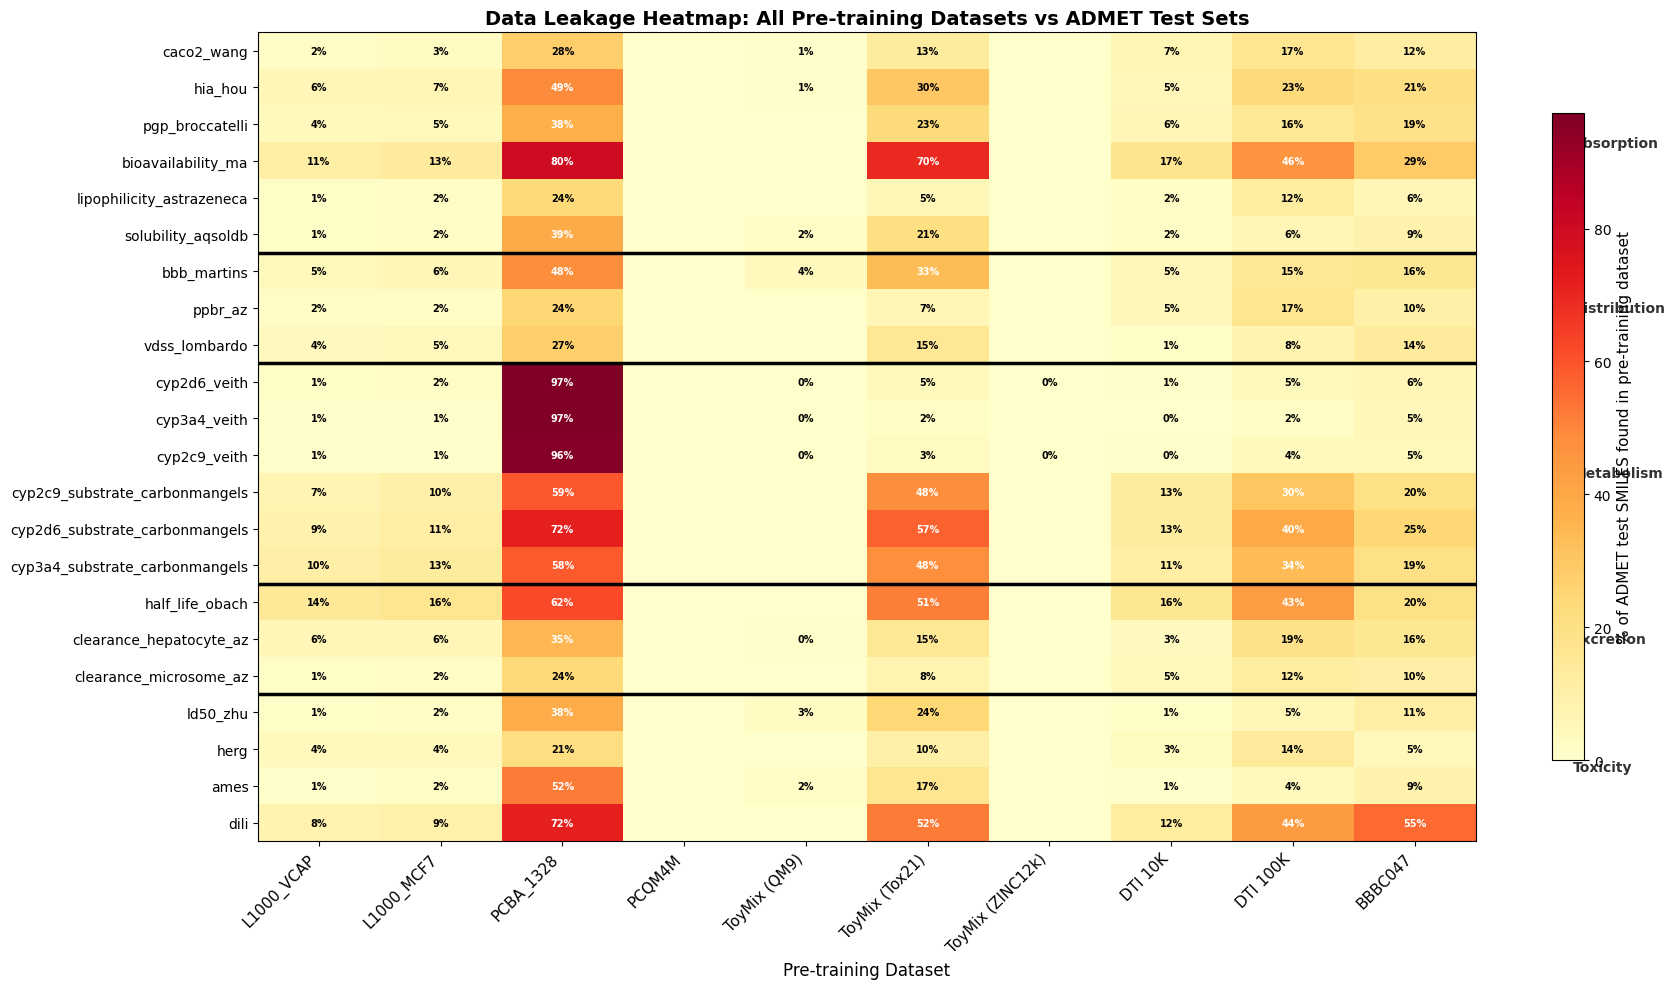

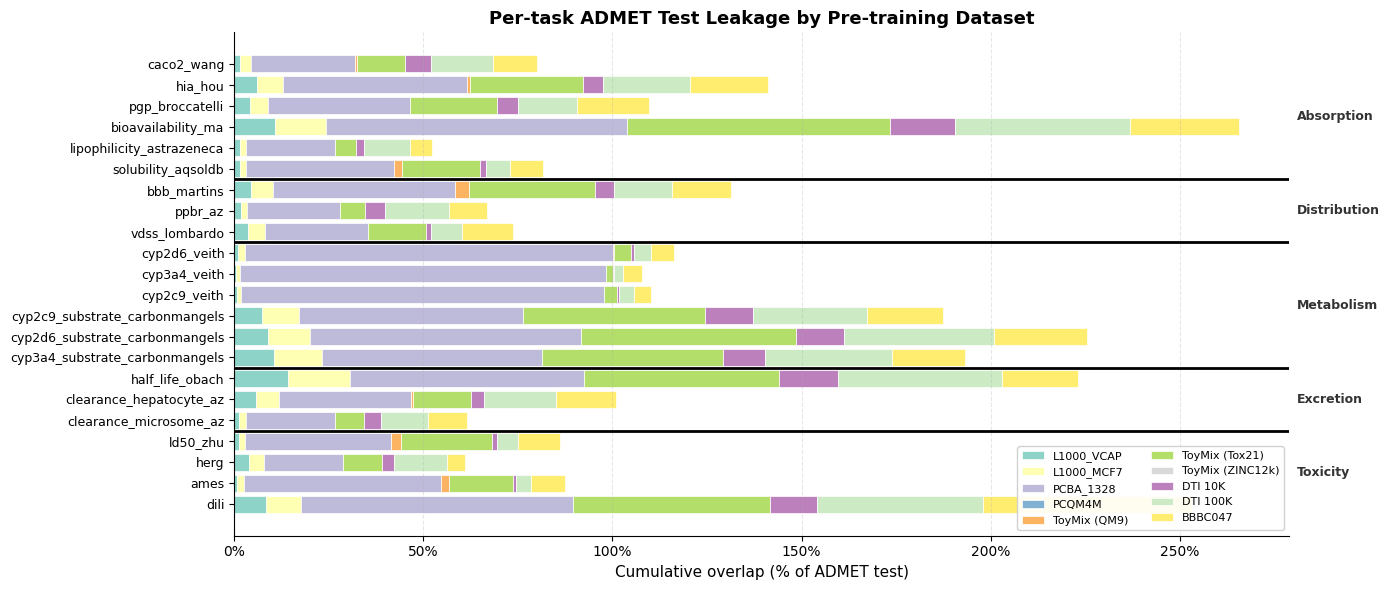

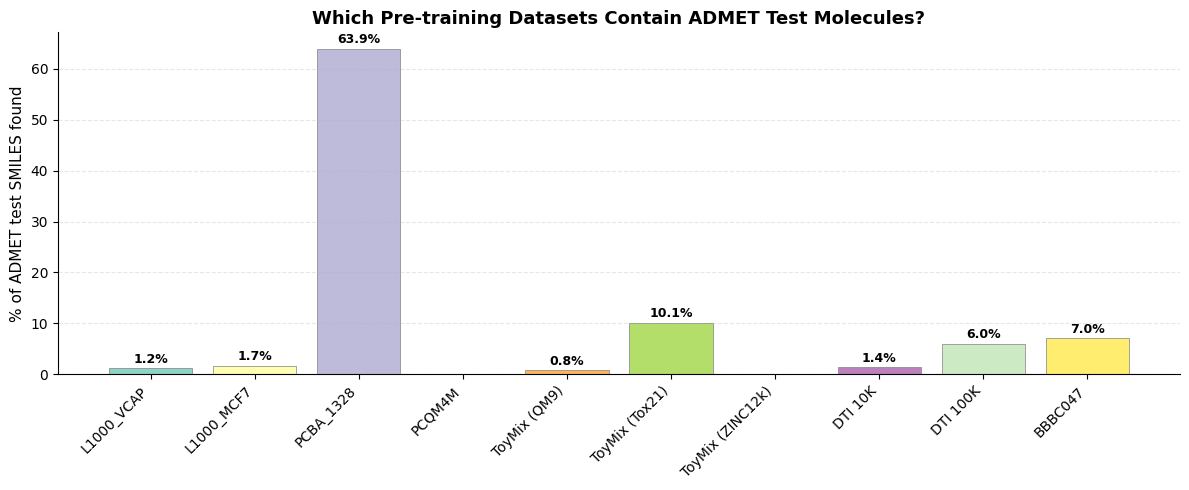


Worst offenders: PCBA (64%), Tox21 (10%), BBBC047 (7%), DTI 100K (6%)
Clean datasets: PCQM4M (0%), ZINC12k (0%)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Canonical ADMET task ordering (A -> D -> M -> E -> T)
ADMET_TASK_ORDER = [
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    'ld50_zhu', 'herg', 'ames', 'dili',
]
CATEGORY_BOUNDS = {'Absorption': (0, 6), 'Distribution': (6, 9), 'Metabolism': (9, 15),
                   'Excretion': (15, 18), 'Toxicity': (18, 22)}

# Collect all pre-training dataset SMILES sets
all_pretrain = {}
for name, smi_set in largemix_smiles.items():
    all_pretrain[name] = smi_set
for name, info in extra_datasets.items():
    p = info["path"]
    col = info["smiles_col"]
    if str(p).endswith(".parquet"):
        smi = pd.read_parquet(p, columns=[col])[col]
    else:
        smi = pd.read_csv(p, usecols=[col])[col]
    all_pretrain[name] = set(smi.dropna().unique())

pretrain_names = list(all_pretrain.keys())
task_names = [t for t in ADMET_TASK_ORDER if t in admet_per_task]

# Build overlap matrix (% of ADMET test found in each pretrain dataset)
matrix = np.zeros((len(task_names), len(pretrain_names)))
for i, task in enumerate(task_names):
    test_smi = set(admet_per_task[task]["test"])
    for j, ds_name in enumerate(pretrain_names):
        overlap = all_pretrain[ds_name] & test_smi
        matrix[i, j] = 100 * len(overlap) / len(test_smi) if test_smi else 0

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(18, 10))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0)

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=10)

# Annotate
for i in range(len(task_names)):
    for j in range(len(pretrain_names)):
        val = matrix[i, j]
        if val > 0:
            color = 'white' if val > 30 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

# Category separators
for cat, (start, end) in CATEGORY_BOUNDS.items():
    if start > 0:
        ax.axhline(y=start - 0.5, color='black', linewidth=2.5)
    mid = (start + end - 1) / 2
    ax.text(len(pretrain_names) + 0.3, mid, cat, ha='left', va='center',
            fontsize=10, fontweight='bold', color='#333')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% of ADMET test SMILES found in pre-training dataset', fontsize=11)

ax.set_title('Data Leakage Heatmap: All Pre-training Datasets vs ADMET Test Sets',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pre-training Dataset', fontsize=12)
plt.tight_layout()
plt.show()

# --- Stacked bar chart: per-task total overlap across datasets ---
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(task_names))
ds_colors = plt.cm.Set3(np.linspace(0, 1, len(pretrain_names)))

for j, (ds_name, color) in enumerate(zip(pretrain_names, ds_colors)):
    vals = matrix[:, j]
    ax.barh(range(len(task_names)), vals, left=bottom, color=color,
            edgecolor='white', linewidth=0.5, label=ds_name, height=0.8)
    bottom += vals

ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Cumulative overlap (% of ADMET test)', fontsize=11)
ax.set_title('Per-task ADMET Test Leakage by Pre-training Dataset', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Category separators
for cat, (start, end) in CATEGORY_BOUNDS.items():
    if start > 0:
        ax.axhline(y=start - 0.5, color='black', linewidth=2)
    mid = (start + end - 1) / 2
    ax.text(ax.get_xlim()[1] + 2, mid, cat, ha='left', va='center',
            fontsize=9, fontweight='bold', color='#333', clip_on=False)

ax.legend(loc='lower right', fontsize=8, ncol=2, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary bar: dataset-level overlap with ADMET test ---
fig, ax = plt.subplots(figsize=(12, 5))
ds_overlap_pcts = []
for ds_name in pretrain_names:
    overlap = all_pretrain[ds_name] & admet_test
    ds_overlap_pcts.append(len(overlap) / len(admet_test) * 100)

bars = ax.bar(range(len(pretrain_names)), ds_overlap_pcts, color=ds_colors,
              edgecolor='grey', linewidth=0.5)

# Annotate bars
for i, (bar, pct) in enumerate(zip(bars, ds_overlap_pcts)):
    if pct > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('% of ADMET test SMILES found', fontsize=11)
ax.set_title('Which Pre-training Datasets Contain ADMET Test Molecules?',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nWorst offenders: PCBA (64%), Tox21 (10%), BBBC047 (7%), DTI 100K (6%)")
print(f"Clean datasets: PCQM4M (0%), ZINC12k (0%)")